In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser

from config import TEST_SIZE, SEED, MAX_DURATION

# Conformación del Dataset Final

In [2]:
df = pd.read_csv('./icbhi/ICBHI_ciclos_metadata.csv')

In [3]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


## Duración de los ciclos respiratorios
La aplicación debería contar con un instructivo mostrando el ritmo de respiración esperado. De esta manera los ciclos detectados por el "segmentador" tendrán mas o menos la misma duración, facilitando la segmentación. 

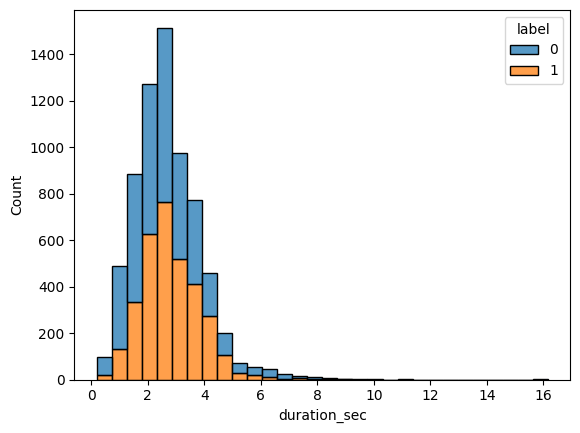

In [4]:
sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

Las duracion sugerida por el instructivo debería estar en el bulk de la distribución observada.  

¿ Qué hacemos con los ciclos que son demasiado cortos? La segmentación no tolera ciclos demasiado cortos.  

Tampoco debería tolerar los demasiado largos, pero esos son pocos y eliminarlos no es tan costoso.

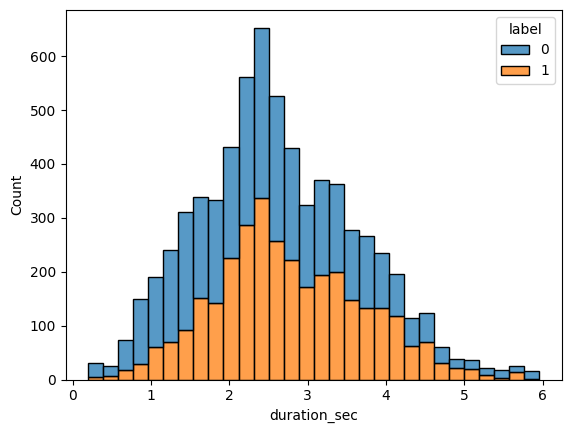

In [5]:
df = df[df['duration_sec'] < MAX_DURATION].copy()

sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

## Versiones del dataset final
Se plantean dos versiones del dataset final:
1. Versión completa: contiene todos los ciclos respiratorios de la ICBHI RSDB.
    + Ventajas:
        + Mayor cantidad de datos
        + Capa MixStyles en CNN puede usar información adicional (?)
        + En caso de extenderse el uso del modelo a estetoscopios digitales no habría que hacer cambios.
    + Desventajas:
        + Dificultad de adaptar al dominio de smartphones
        + Costo computacional alto (mi máquina no puede correr CV se SK-Learn)
2. Versión filtrada: sólo los audios grabados con el micrófono AKGC417L o desde la tráquea.
    + Ventajas:
        + Menor costo computacional
        + Menor dificultad en adaptar al dominio
        + Más representativo de los audios esperados en producción
    + Desventajas:
        + Pérdida de datos
        + Más específico al caso (puede ser una ventaja también, no aprendería cosas innecesarias)

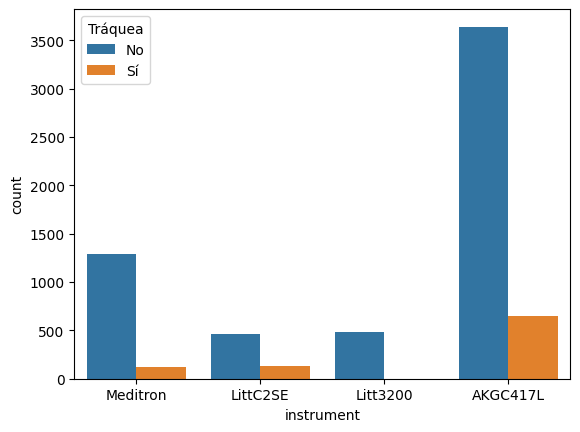

In [6]:
sns.countplot(data=df, x='instrument', hue=df['location'] == 'Tc')
plt.legend(title='Tráquea', labels=['No', 'Sí']);

In [7]:
dataset_completo = df.copy()

dataset_filtrado = df[(df['instrument'] == 'AKGC417L') | (df['location'] == 'Tc')].copy()

## Balancear

Primero miramos la etiqueta objetivo del futuro modelo

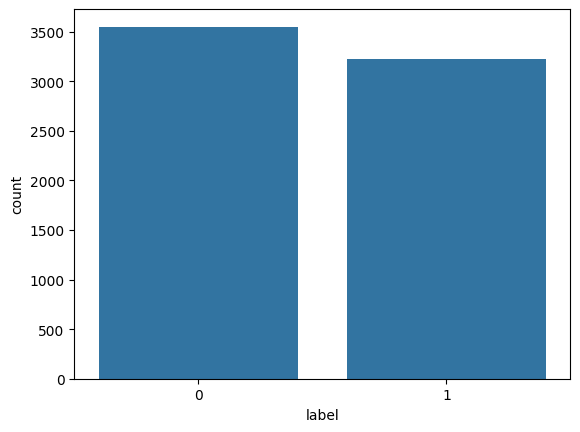

In [8]:
sns.countplot(data=df, x='label');

La variable ``sex`` presenta un desbalance importante. Para evitarlo se pueden usar técnicas durante en el pipeline del modelo final con ``fairlearn`` 

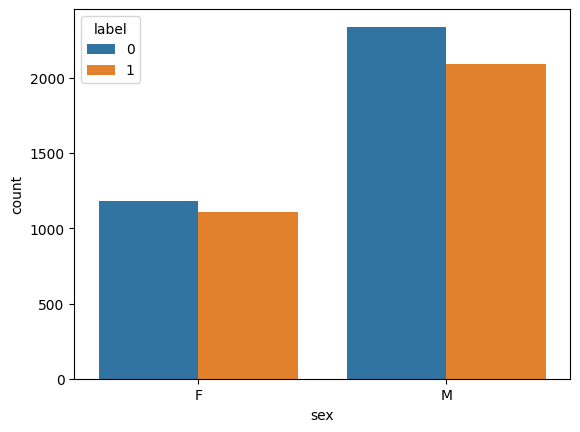

In [9]:
sns.countplot(data=df, x='sex', hue='label');

Vemos las edades, faltan datos entre 20 y 40. No se puede hacer mucho porque no hay datos que duplicar. Simplemente habrá que documentar la limitación.

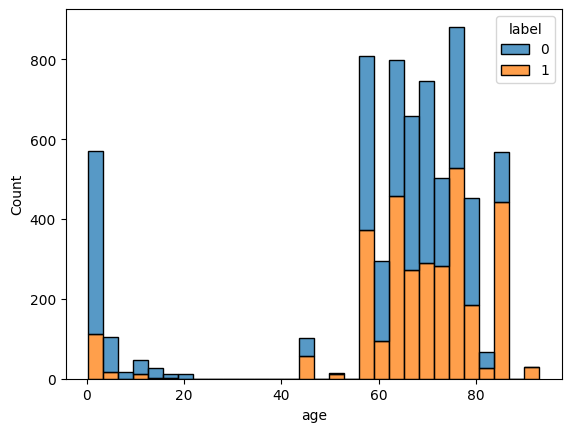

In [10]:
sns.histplot(data=df, x='age', bins=30, hue='label', multiple='stack');

Ver los pacientes de bronchiolitis menores de 20.

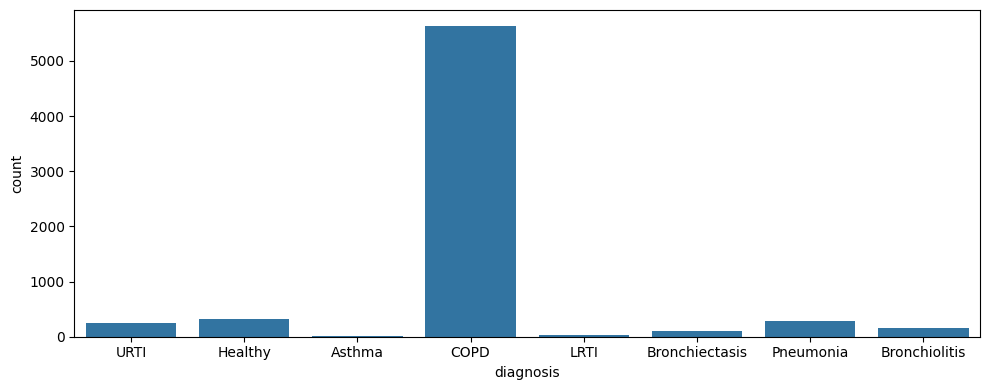

In [11]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='diagnosis')
plt.tight_layout();

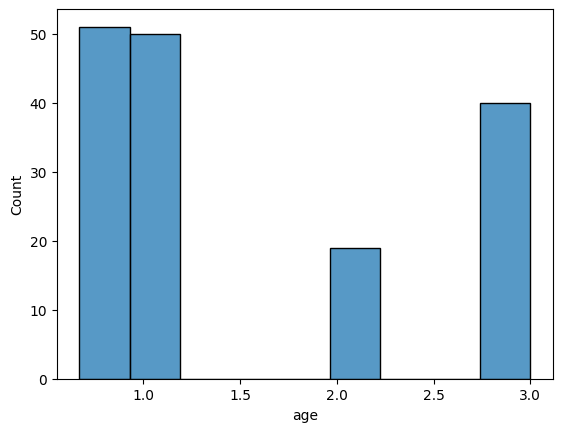

In [12]:
sns.histplot(data=df[df['diagnosis'] == 'Bronchiolitis'], x='age');

Son sólo 160 ciclos respiratorios, habría muchos duplicados. Además, son todos menos de 3 años y la idea era ver adolescentes.

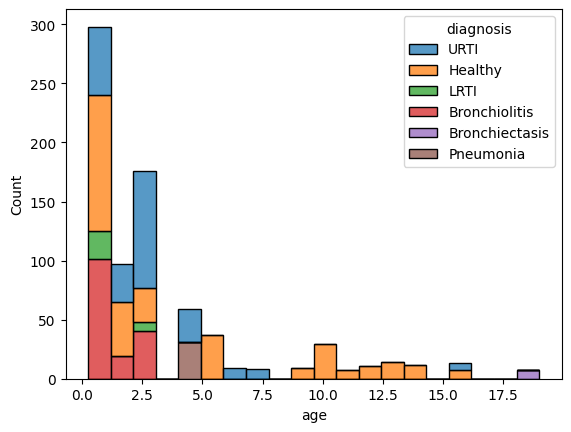

In [13]:
sns.histplot(data=df[df['age'] < 20], x='age', bins=20, hue='diagnosis', multiple='stack');

Los adolescentes son pacientes sanos

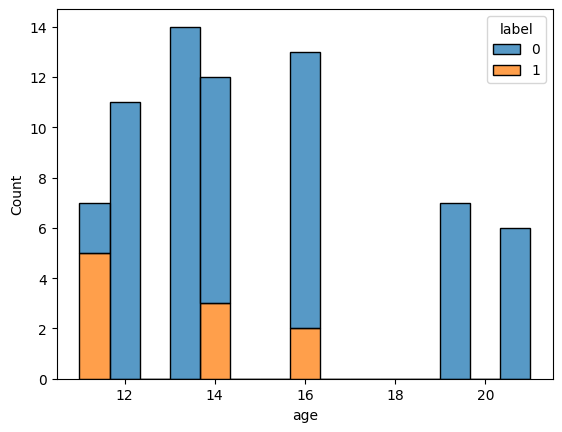

In [14]:
sns.histplot(data=df[(df['age'] < 25) & (df['age'] > 10)], x='age', hue='label', multiple='stack', bins=15);

Como no hay pacientes de EPOC el grupo de los menores de 20 puede ser eliminado del dataset final si llega a ser necesario achicar el mismo.

## Separar en Conjuntos de Entrenamiento y Prueba fijos

Guardo los paths de los archivos de ambos conjuntos

In [ ]:
train, test =  train_test_split(df[['cycle_wav_file', 'label']], test_size=TEST_SIZE, random_state=SEED, stratify=df['label'])

os.makedirs('./dataset/ciclos_train', exist_ok=True)
os.makedirs('./dataset/ciclos_test', exist_ok=True)

train.to_csv('./dataset/ciclos_train/train_filenames.csv', index=False)
test.to_csv('./dataset/ciclos_test/test_filenames.csv', index=False)

# Domain Shift

1. Resampleo a 16 kHz
2. Agrego ruido (opcional) TODO
3. Filtro pasa bandas (300 - 4000 Hz)

# Armado de los dos datasets

In [2]:
train = pd.read_csv('./dataset/ciclos_train/train_filenames.csv')
test = pd.read_csv('./dataset/ciclos_test/test_filenames.csv')

In [3]:
X_train = ['./dataset/ciclos/' + f for f in train['cycle_wav_file']]
X_test = ['./dataset/ciclos/' + f for f in test['cycle_wav_file']]
y_train = train['label'].values
y_test = test['label'].values

## Mel espectrogramas

Dejamos el escalado para el modelado

In [4]:
pipeline_melspec = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

In [5]:
X_train_melspecs = pipeline_melspec.fit_transform(X_train)
X_test_melspecs = pipeline_melspec.transform(X_test)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


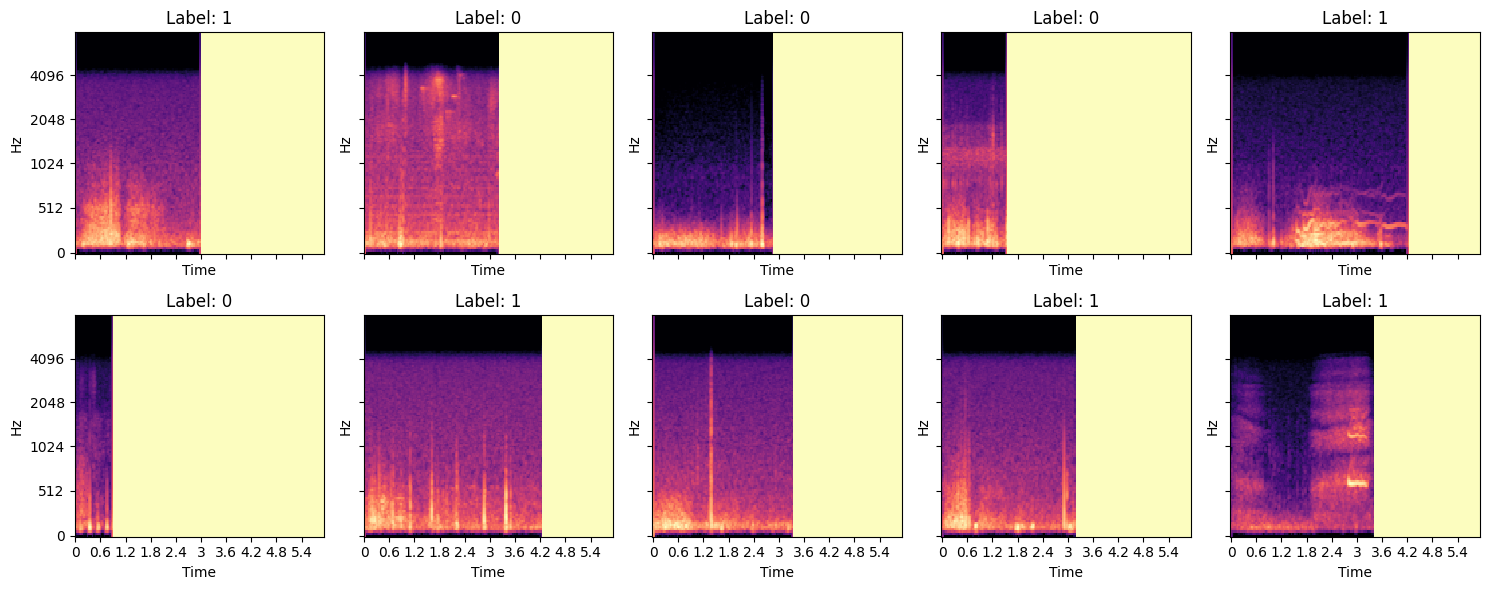

In [6]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_melspecs[i].reshape(128, -1), sr=16000, x_axis='time', y_axis='mel', n_fft=1024, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train[i]}')
plt.tight_layout();

In [7]:
np.savez_compressed(
    './dataset/ciclos_train/train_melspectrogram.npz',
    X=X_train_melspecs,
    y=y_train
)

np.savez_compressed(
    './dataset/ciclos_test/test_melspectrogram.npz',
    X=X_test_melspecs,
    y=y_test
)

## Features

In [8]:
pipeline_feature_extraction = Pipeline([
    ('resampler', Resampler()),
    ('wavelet_denoiser', WaveletDenoiser()),
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

In [9]:
X_train_fe = pipeline_feature_extraction.fit_transform(X_train)
X_test_fe = pipeline_feature_extraction.transform(X_test)

In [11]:
X_train_fe_df = pd.DataFrame(X_train_fe, columns=[
    'mfcc_' + str(i) for i in range(1, 14)] + [
] + [
    'zcr',
    'energy',
    'spectral_centroid',
    'spectral_rolloff',
    'ber',
    'spectral_flatness'
])

X_test_fe_df = pd.DataFrame(X_test_fe, columns=[
    'mfcc_' + str(i) for i in range(1, 14)] + [
] + [
    'zcr',
    'energy',
    'spectral_centroid',
    'spectral_rolloff',
    'ber',
    'spectral_flatness'
])

X_train_fe_df['label'] = y_train
X_test_fe_df['label'] = y_test

In [12]:
X_train_fe_df.to_csv('./dataset/ciclos_train/train_features.csv', index=False)
X_test_fe_df.to_csv('./dataset/ciclos_test/test_features.csv', index=False)